Olist E-Commerce Sales & Operations Intelligence

Dataset
Brazilian E-Commerce Public Dataset by Olist — Kaggle

The dataset contains roughly 100,000 orders from 2016–2018 and 9 related CSV files covering orders, customers, products, sellers, payments, reviews and geolocation.

STEP 1 — Set Up the Project & Download the Dataset
We first create a clean project environment and obtain the raw data. We will not clean or modify the original files yet.

1.1 Download the Dataset
You should see CSV files similar to:
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_orders_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv

1.2 Create the Project Folder
1.3 Install Required Python Libraries


In [4]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy pyodbc


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# 1.4 Import the Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import os

In [6]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 2.3.0
NumPy: 2.2.6


In [7]:
# 1.5 Define Our Data Path

In [8]:
data_path = "C:/Users/Saurabh/Analytics_project/raw_data"

In [9]:
os.listdir(data_path)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [10]:
# 1.6 Load the First Dataset
orders = pd.read_csv(
    data_path + "/olist_orders_dataset.csv"
)

In [11]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
orders.shape

(99441, 8)

In [13]:
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

Rows: 99441
Columns: 8


In [14]:
# 1.7 Load All Tables

In [15]:
customers = pd.read_csv(
    data_path + "/olist_customers_dataset.csv"
)

order_items = pd.read_csv(
    data_path + "/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    data_path + "/olist_products_dataset.csv"
)

sellers = pd.read_csv(
    data_path + "/olist_sellers_dataset.csv"
)

payments = pd.read_csv(
    data_path + "/olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    data_path + "/olist_order_reviews_dataset.csv"
)

geolocation = pd.read_csv(
    data_path + "/olist_geolocation_dataset.csv"
)

category_translation = pd.read_csv(
    data_path + "/product_category_name_translation.csv"
)

In [16]:
# 1.8 Put Everything Into a Dictionary

# This will make our later analysis easier.


datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "reviews": reviews,
    "geolocation": geolocation,
    "category_translation": category_translation
}

In [17]:
# # 1.9 Create Our First Data Inventory
# Why are we doing this?

# Instead of manually checking nine datasets one by one, we'll create a data inventory.

# This is a common analytical practice.

for name, df in datasets.items():
    print(
        f"{name:25} "
        f"Rows: {df.shape[0]:7} | "
        f"Columns: {df.shape[1]:3}"
    )

customers                 Rows:   99441 | Columns:   5
orders                    Rows:   99441 | Columns:   8
order_items               Rows:  112650 | Columns:   7
products                  Rows:   32951 | Columns:   9
sellers                   Rows:    3095 | Columns:   4
payments                  Rows:  103886 | Columns:   5
reviews                   Rows:   99224 | Columns:   7
geolocation               Rows: 1000163 | Columns:   5
category_translation      Rows:      71 | Columns:   2


In [18]:
# 1.10 Save the Inventory

inventory = pd.DataFrame({
    "table": datasets.keys(),
    "rows": [df.shape[0] for df in datasets.values()],
    "columns": [df.shape[1] for df in datasets.values()]
})

inventory

,table,rows,columns
0,customers,99441,5
1,orders,99441,8
2,order_items,112650,7
3,products,32951,9
4,sellers,3095,4
5,payments,103886,5
6,reviews,99224,7
7,geolocation,1000163,5
8,category_translation,71,2


In [19]:
inventory.to_csv(
    "C:/Users/Saurabh/Analytics_project/outputs/tables/data_inventory.csv",
    index=False
)

STEP 2 — Understand the Data & Check Data Quality

Before cleaning, joining, or analyzing anything, we need to understand what each table contains and whether the data is reliable.
this will answer -->
<!-- How many rows/columns does each table have?
What does each column mean?
What are the data types?
Where are the missing values?
Are there duplicates?
What are the important keys?
How are the tables related? -->

In [20]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [21]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)
    print(df.head(3))


CUSTOMERS
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  

ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:1

In [22]:
# check datatypes
for name, df in datasets.items():
    print("\n", name)
    print(df.dtypes)


 customers
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

 orders
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

 order_items
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

 products
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_we

In [23]:
# Check Missing Values
for name, df in datasets.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0].sort_values(
        ascending=False
    )

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print(missing)


CUSTOMERS
Series([], dtype: int64)

ORDERS
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

ORDER_ITEMS
Series([], dtype: int64)

PRODUCTS
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS
Series([], dtype: int64)

PAYMENTS
Series([], dtype: int64)

REVIEWS
review_comment_title      87656
review_comment_message    58247
dtype: int64

GEOLOCATION
Series([], dtype: int64)

CATEGORY_TRANSLATION
Series([], dtype: int64)


In [24]:
# Calculate Missing Percentage
missing_report = {}

for name, df in datasets.items():

    missing_pct = (
        df.isnull().sum() / len(df) * 100
    )

    missing_pct = (
        missing_pct[missing_pct > 0]
        .sort_values(ascending=False)
    )

    missing_report[name] = missing_pct

    print("\n", name)
    print(missing_pct)


 customers
Series([], dtype: float64)

 orders
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64

 order_items
Series([], dtype: float64)

 products
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

 sellers
Series([], dtype: float64)

 payments
Series([], dtype: float64)

 reviews
review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

 geolocation
Series([], dtype: float64)

 category_translation
Series([], dtype: float64)


In [25]:
# Investigate Missing Values in Orders
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [26]:
orders[
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].isnull().sum()

order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [27]:
# # We do not immediately fill them with the mean.

# Why?

# Because a missing delivery date may mean the order was:

# Cancelled
# Unavailable
# Still processing
# Not delivered
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isna()
)

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


In [28]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [29]:
## Check Order Status
orders["order_status"].value_counts(
    normalize=True
) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [30]:
## Check Duplicates
# Duplicate records can distort our calculations.

for name, df in datasets.items():

    print(
        f"{name:25} "
        f"Duplicate rows: {df.duplicated().sum()}"
    )

customers                 Duplicate rows: 0
orders                    Duplicate rows: 0
order_items               Duplicate rows: 0
products                  Duplicate rows: 0
sellers                   Duplicate rows: 0
payments                  Duplicate rows: 0
reviews                   Duplicate rows: 0
geolocation               Duplicate rows: 261831
category_translation      Duplicate rows: 0


In [31]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [32]:
products["product_id"].duplicated().sum()

np.int64(0)

In [33]:
## Check Unique Values
# order status
orders["order_status"].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [34]:
# Payment type
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [35]:
# Review score
reviews["review_score"].unique()

array([4, 5, 1, 3, 2])

In [36]:
# Customer states
customers["customer_state"].nunique()

27

In [37]:
customers["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [38]:
# Check Numerical Variables

# For order_items:

order_items[
    [
        "price",
        "freight_value"
    ]
].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [39]:
## First Analytical Question
# How many unique customers and orders do we have?
total_orders = orders["order_id"].nunique()

total_customers = customers[
    "customer_unique_id"
].nunique()

print("Total Orders:", total_orders)
print("Total Unique Customers:", total_customers)

# Why customer_unique_id instead of customer_id?

# Because for customer behavior analysis, we want to distinguish the actual customer from an individual order/customer record.

# This distinction becomes important when we analyze repeat purchasing later.

Total Orders: 99441
Total Unique Customers: 96096


In [40]:
## Create a Data Quality Summary

# Let's create a reusable report.

quality_report = []

for name, df in datasets.items():

    quality_report.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells": df.isnull().sum().sum(),
        "missing_percentage":
            round(
                df.isnull().sum().sum()
                / df.size * 100,
                2
            )
    })

quality_report = pd.DataFrame(
    quality_report
)

quality_report

,table,rows,columns,duplicate_rows,missing_cells,missing_percentage
0,customers,99441,5,0,0,0.00
1,orders,99441,8,0,4908,0.62
2,order_items,112650,7,0,0,0.00
3,products,32951,9,0,2448,0.83
4,sellers,3095,4,0,0,0.00
5,payments,103886,5,0,0,0.00
6,reviews,99224,7,0,145903,21.01
7,geolocation,1000163,5,261831,0,0.00
8,category_translation,71,2,0,0,0.00


In [41]:
quality_report.to_csv(
    "C:/Users/Saurabh/Analytics_project/outputs/tables/data_quality_report.csv",
    index=False
)

STEP 3 — Data Preprocessing

<!-- Clean & Prepare the Data

We'll handle the issues we actually found rather than blindly applying generic cleaning.

We'll do:

Convert date columns properly
Handle missing values based on business meaning
Validate IDs and relationships
Translate product categories
Check numerical outliers
Create clean analytical columns
Build the order-level analytical dataset
Validate the cleaned dataset
Prepare the cleaned data for SQL Server import -->

we'll convert the raw data into analysis-ready data while preserving the original business meaning.

In [42]:
# # Convert Date Columns
# Why?

# Currently, dates are probably stored as object/strings. We need proper datetime format so we can calculate:

# Delivery days
# Delivery delays
# Monthly revenue
# Yearly trends
# Order processing time

In [43]:
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [44]:
orders[order_date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [45]:
# Also convert the order-item date
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"],
    errors="coerce"
)
orders[order_date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [46]:
## Understand Missing Values
# We will not fill or delete missing values blindly.

# First, let's identify exactly which columns have missing values.

missing_orders = orders.isnull().sum()
missing_orders = missing_orders[missing_orders > 0].sort_values(ascending=False)

missing_orders


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

In [47]:
missing_products = products.isnull().sum()
missing_products = missing_products[missing_products > 0].sort_values(ascending=False)

missing_products

product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [48]:
missing_reviews = reviews.isnull().sum()
missing_reviews = missing_reviews[missing_reviews > 0].sort_values(ascending=False)

missing_reviews

review_comment_title      87656
review_comment_message    58247
dtype: int64

In [49]:
## Missing Values Analysis

# Your outputs are clear. Do not delete these rows.

# 1. Orders
# Column	Missing	Treatment
# order_delivered_customer_date	-> 2,965-> Keep as missing
# order_delivered_carrier_date	-> 1,783->	Keep as missing
# order_approved_at	-> 160-> Keep as missing

# These missing dates can represent orders that were cancelled, unavailable, or not completed at that stage. We need to preserve them for operational analysis.

In [50]:
## 2. Products

# 610 products are missing:

# product_category_name
# product_name_length
# product_description_length
# product_photos_qty

# These are likely the same 610 products.

# The remaining missing values are only 2 products for physical dimensions/weight.

# We will not delete these products.

In [51]:
# 3. Reviews
# review_comment_title      87,656
# review_comment_message    58,247

# This is not a data-quality problem.

# A customer can submit a rating without writing a title/message.

# So we should keep these as NaN rather than replacing them with fake information.

In [52]:
## Check Why Order Dates Are Missing
# Before deciding anything about the missing order dates, let's connect them with order_status.
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isna()
)

order_delivered_customer_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


In [53]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_carrier_date"].isna()
)

order_delivered_carrier_date,False,True
order_status,,
approved,0,2
canceled,75,550
created,0,5
delivered,96476,2
invoiced,0,314
processing,0,301
shipped,1107,0
unavailable,0,609


In [54]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [55]:
# #Order Date Findings

# Your outputs confirm that the missing dates are meaningful, not random errors.

# What we found
# delivered orders:
# Only 8 missing customer delivery dates.
# Only 2 missing carrier dates.
# These are very small exceptions.
# shipped orders:
# 1,107 have no customer delivery date yet.
# This is expected because they are not marked delivered.
# canceled:
# Many missing delivery dates, which is expected.
# unavailable:
# 609 orders have no delivery dates.
# processing, invoiced, created, approved:
# Missing delivery dates are expected because these orders haven't reached delivery.
# Decision

# We will keep the missing dates as NaN.

# We will not fill them with:

# 0
# mean/median
# estimated dates
# forward/backward fill

# That would create fake operational data.

In [56]:
# #Create Delivery & Delay Metrics

# Now we can create the most important operational variables.

# Why?

# These will later be used for:

# Delivery performance
# Late-delivery analysis
# State/category analysis
# SQL queries
# Dashboard KPIs

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

In [57]:
# Create estimated delay:

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

In [58]:
# Create late-delivery flag:

orders["is_late"] = np.where(
    orders["delivery_delay_days"].notna(),
    orders["delivery_delay_days"] > 0,
    np.nan
)

In [59]:
# Check the result
orders[
    [
        "order_status",
        "delivery_days",
        "delivery_delay_days",
        "is_late"
    ]
].head(10)

,order_status,delivery_days,delivery_delay_days,is_late
0,delivered,8.436574,-7.107488,0.0
1,delivered,13.782037,-5.355729,0.0
2,delivered,9.394213,-17.245498,0.0
3,delivered,13.208750,-12.980069,0.0
4,delivered,2.873877,-9.238171,0.0
5,delivered,16.542245,-5.543113,0.0
6,invoiced,NaN,NaN,NaN
7,delivered,9.989826,-11.461215,0.0
8,delivered,9.818762,-31.410995,0.0
9,delivered,18.221852,-6.281597,0.0


In [60]:
orders[["delivery_days", "delivery_delay_days"]].describe()

,delivery_days,delivery_delay_days
count,96476.000000,96476.000000
mean,12.558702,-11.179120
std,9.546530,10.186113
min,0.533414,-146.016123
25%,6.766403,-16.244384
50%,10.217755,-11.948941
75%,15.720327,-6.390000
max,209.628611,188.975081


In [61]:
# What these mean

# delivery_days

# Actual number of days from purchase to customer delivery.

# delivery_delay_days

# Positive = delivered late
# Negative = delivered before estimated date
# Zero = delivered exactly on estimated date.

# is_late

# True = late delivery
# False = on-time/early
# NaN = not delivered, so lateness cannot be determined.

✅  Delivery Metrics Check

The output looks reasonable overall, but there are some extreme values we should investigate before using these metrics.

Key findings
Metric	Result	Meaning
Avg delivery time	12.56 days	Reasonable overall
Median delivery time	10.22 days	Typical order is around 10 days
Maximum delivery time	209.63 days	⚠️ Very high — investigate
Avg delay	−11.18 days	Orders were generally delivered before estimate
Median delay	−11.95 days	Typical order was ~12 days early
Maximum delay	188.98 days	⚠️ Extreme late delivery
Minimum delay	−146.02 days	⚠️ Extremely early relative to estimate
Important point

Don't remove these values yet.

For a portfolio project, investigating extreme operational values is actually valuable. We need to determine whether they are:

genuine unusual orders,
date/data issues,
or legitimate long/early deliveries.

In [62]:
# Investigate Extreme Delivery Values
# 1. Check the 10 longest deliveries
orders[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "delivery_delay_days"
    ]
].sort_values(
    "delivery_days",
    ascending=False
).head(10)

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,209.628611,181.608785
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,2018-03-15,208.351759,188.975081
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,195.634016,165.633912
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,2017-04-17,194.850174,155.606447
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,194.633611,166.583380
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,194.049583,161.609965
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,191.463542,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,189.863160,167.708414
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,188.134618,159.609931
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,187.743843,162.718345


In [63]:
# 2. Check the most extreme early/late deliveries
orders[
    [
        "order_id",
        "order_status",
        "delivery_days",
        "delivery_delay_days"
    ]
].sort_values(
    "delivery_delay_days"
).head(10)

,order_id,order_status,delivery_days,delivery_delay_days
40094,0607f0efea4b566f1eb8f7d3c2397320,delivered,3.576157,-146.016123
15791,c72727d29cde4cf870d569bf65edabfd,delivered,6.851736,-139.397396
57160,eec7f369423b033e549c02f3c5381205,delivered,20.826933,-134.308530
86444,c2bb89b5c1dd978d507284be78a04cb2,delivered,16.630069,-123.433403
67488,40dc2ba6f322a17626aac6244332828c,delivered,7.673634,-108.424225
79449,1a695d543b7302aa9446c8d5fbd632bf,delivered,12.489977,-83.070567
62706,39e0115911bf404857e14baa7f097feb,delivered,11.752986,-82.921829
95849,559eea5a72341a4c82dbce9884277cb7,delivered,13.242211,-77.324421
63537,38930f76efb00b138f4d632e4d557341,delivered,11.231910,-77.193299
37491,c5132855100a12d63ed4e8ae05f9594d,delivered,12.234109,-77.151273


In [64]:
orders[
    [
        "order_id",
        "order_status",
        "delivery_days",
        "delivery_delay_days"
    ]
].sort_values(
    "delivery_delay_days",
    ascending=False
).head(10)

,order_id,order_status,delivery_days,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,208.351759,188.975081
19590,ca07593549f1816d26a572e06dc1eab6,delivered,209.628611,181.608785
11399,47b40429ed8cce3aee9199792275433f,delivered,191.463542,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,189.863160,167.708414
89130,285ab9426d6982034523a855f55a885e,delivered,194.633611,166.583380
61610,440d0d17af552815d15a9e41abe49359,delivered,195.634016,165.633912
68769,c27815f7e3dd0b926b58552628481575,delivered,187.743843,162.718345
40847,d24e8541128cea179a11a65176e0a96f,delivered,175.223819,161.775336
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,194.049583,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,188.134618,159.609931


In [65]:
# Why are we doing this?

# We need to understand the outliers before deciding whether to keep, cap, or exclude them.

# For the final project, we'll document the decision rather than silently deleting unusual observations.

In [66]:
# Create an Outlier Flag
# Why?

# We want to identify unusually long deliveries without deleting them.

# First calculate the 99th percentile:

delivery_p99 = orders["delivery_days"].quantile(0.99)

delivery_p99

np.float64(46.04991319444444)

In [67]:
# Then create a flag:

orders["delivery_outlier"] = np.where(
    orders["delivery_days"].notna(),
    orders["delivery_days"] > delivery_p99,
    np.nan
)

In [68]:
# Check:

orders["delivery_outlier"].value_counts(dropna=False)

delivery_outlier
0.0    95511
NaN     2965
1.0      965
Name: count, dtype: int64

In [69]:
# Save a Checkpoint

# Before moving further, save our updated orders dataframe so we don't lose the work.

orders.to_csv(
    "C:/Users/Saurabh/Analytics_project/outputs/tables/orders_clean_stage1.csv",
    index=False
)

In [73]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [74]:
products.rename(
    columns={
        "product_category_name_english": "product_category"
    },
    inplace=True
)

In [75]:
products["product_category"] = products["product_category"].fillna(
    "unknown"
)

In [77]:
# main analytical order-item dataset

In [78]:
order_items_analysis = (
    order_items
    .merge(
        products[
            ["product_id", "product_category"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        orders[
            [
                "order_id",
                "customer_id",
                "order_status",
                "order_purchase_timestamp",
                "order_delivered_customer_date",
                "order_estimated_delivery_date",
                "delivery_days",
                "delivery_delay_days",
                "is_late",
                "delivery_outlier"
            ]
        ],
        on="order_id",
        how="left"
    )
)

In [79]:
order_items_analysis.shape , order_items_analysis.head()

((112650, 17),
                            order_id  order_item_id  \
 0  00010242fe8c5a6d1ba2dd792cb16214              1   
 1  00018f77f2f0320c557190d7a144bdd3              1   
 2  000229ec398224ef6ca0657da4fc703e              1   
 3  00024acbcdf0a6daa1e931b038114c75              1   
 4  00042b26cf59d7ce69dfabb4e55b4fd9              1   
 
                          product_id                         seller_id  \
 0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
 1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
 2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
 3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
 4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   
 
   shipping_limit_date   price  freight_value product_category  \
 0 2017-09-19 09:45:35   58.90          13.29       cool_stuff   
 1 2017-05-03 11:05:13  239.90          19.93         pet_shop   
 2 2018-0

In [80]:
# Why this matters

# We'll now have item + product + order + delivery information together, allowing us to analyze:

# Revenue
# Product categories
# Freight
# Delivery performance
# Late orders
# Order status

# without repeatedly joining the raw tables.

STEP 4 — Build Final Analytical Datasets
Why?

We'll create:

Order-level dataset → KPIs, customers, delivery, payments, reviews
Item-level dataset → categories, products, sellers, revenue, freight

This also prevents double-counting revenue later.

In [82]:
# Create Order-Level Dataset


# Item-level financial summary per order
order_financials = (
    order_items.groupby("order_id")
    .agg(
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count")
    )
    .reset_index()
)

# Payment summary per order
payment_summary = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_installments=("payment_installments", "max")
    )
    .reset_index()
)

# Review summary per order
review_summary = (
    reviews.groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)
# Customer information
customer_info = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

# Build final order-level table
order_analysis = (
    orders
    .merge(order_financials, on="order_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(review_summary, on="order_id", how="left")
    .merge(customer_info, on="customer_id", how="left")
)

order_analysis.shape

(99441, 21)

In [83]:
# Add Important Business Metrics
order_analysis["total_order_value"] = (
    order_analysis["product_revenue"]
    + order_analysis["freight_value"]
)

order_analysis["freight_ratio"] = (
    order_analysis["freight_value"]
    / order_analysis["product_revenue"]
)

order_analysis["order_month"] = (
    order_analysis["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [84]:
# Save the Final Dataset
order_analysis.to_csv(
    "C:/Users/Saurabh/Analytics_project/outputs/tables/order_analysis.csv",
    index=False
)

order_items_analysis.to_csv(
    "C:/Users/Saurabh/Analytics_project/outputs/tables/order_items_analysis.csv",
    index=False
)

In [85]:
# Final Validation

order_analysis[
    [
        "order_id",
        "customer_unique_id",
        "product_revenue",
        "freight_value",
        "total_order_value",
        "delivery_days",
        "delivery_delay_days",
        "review_score",
        "customer_state"
    ]
].head()

,order_id,customer_unique_id,product_revenue,freight_value,total_order_value,delivery_days,delivery_delay_days,review_score,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,38.71,8.436574,-7.107488,4.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,141.46,13.782037,-5.355729,4.0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,179.12,9.394213,-17.245498,5.0,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,72.20,13.208750,-12.980069,5.0,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,28.62,2.873877,-9.238171,5.0,SP


In [86]:
order_analysis.shape

(99441, 24)

Why this is important

We now have the core analytical structure:

                    ORDER ANALYSIS
                         │
        ┌────────────────┼────────────────┐
        ↓                ↓                ↓
     SALES          OPERATIONS        CUSTOMER
        │                │                │
   Revenue/AOV      Delivery/Late     Repeat users
   Freight          Delay             State
   Payments         Performance       Reviews

In [88]:
'**----------------------------------------------------------------------------------------**'

'**----------------------------------------------------------------------------------------**'

STEP 5 — Business EDA

We'll focus only on analyses that are useful for your portfolio:

Sales & revenue trend
Top product categories
State-wise performance
Delivery performance
Freight cost
Customer/review behavior

We'll generate both numbers and charts so these can later feed the dashboard.

In [89]:
# Overall Business KPIs
# Why?

# First establish the basic scale of the business.



total_orders = order_analysis["order_id"].nunique()
total_customers = order_analysis["customer_unique_id"].nunique()
total_revenue = order_analysis["product_revenue"].sum()
total_freight = order_analysis["freight_value"].sum()
aov = total_revenue / total_orders
avg_rating = order_analysis["review_score"].mean()

print("Total Orders:", total_orders)
print("Unique Customers:", total_customers)
print("Total Revenue:", round(total_revenue, 2))
print("Total Freight:", round(total_freight, 2))
print("Average Order Value:", round(aov, 2))
print("Average Review Score:", round(avg_rating, 2))

Total Orders: 99441
Unique Customers: 96096
Total Revenue: 13591643.7
Total Freight: 2251909.54
Average Order Value: 136.68
Average Review Score: 4.09


KPI	Meaning
Total Orders	Business transaction volume
Unique Customers	Customer base
Revenue	Product sales value
Freight	Logistics cost
AOV	Average revenue per order
Rating	Customer experience

In [90]:
# Monthly Revenue Trend
# Why?

# This tells us whether sales are:

# growing,
# declining,
# seasonal,
# or experiencing unusual periods.

monthly_sales = (
    order_analysis
    .groupby("order_month")
    .agg(
        revenue=("product_revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales

,order_month,revenue,orders
0,2016-09,267.36,4
1,2016-10,49507.66,324
2,2016-12,10.90,1
3,2017-01,120312.87,800
4,2017-02,247303.02,1780
5,2017-03,374344.30,2682
6,2017-04,359927.23,2404
7,2017-05,506071.14,3700
8,2017-06,433038.60,3245
9,2017-07,498031.48,4026


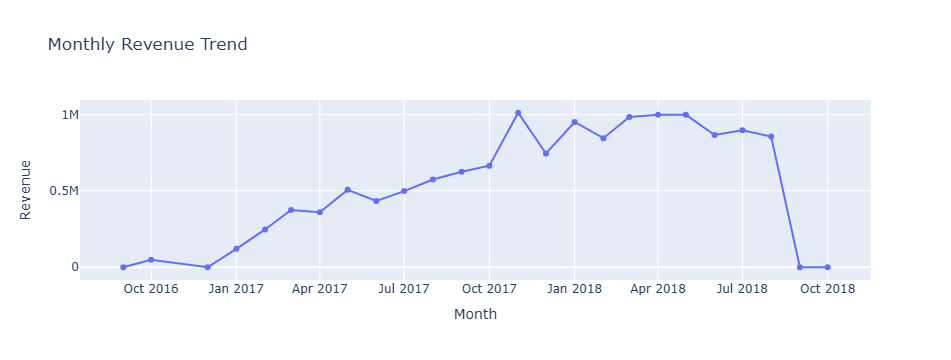

In [91]:
#Create the chart
fig = px.line(
    monthly_sales,
    x="order_month",
    y="revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue"
)

fig.show()

In [92]:
# calculate monthly growth
monthly_sales["revenue_growth_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)

monthly_sales

,order_month,revenue,orders,revenue_growth_pct
0,2016-09,267.36,4,NaN
1,2016-10,49507.66,324,1.841723e+04
2,2016-12,10.90,1,-9.997798e+01
3,2017-01,120312.87,800,1.103688e+06
4,2017-02,247303.02,1780,1.055499e+02
5,2017-03,374344.30,2682,5.137069e+01
6,2017-04,359927.23,2404,-3.851286e+00
7,2017-05,506071.14,3700,4.060374e+01
8,2017-06,433038.60,3245,-1.443128e+01
9,2017-07,498031.48,4026,1.500857e+01


In [93]:
# From this output we'll identify:

# Highest-revenue month
# Lowest-revenue month
# Growth/decline periods
# Major changes worth investigating

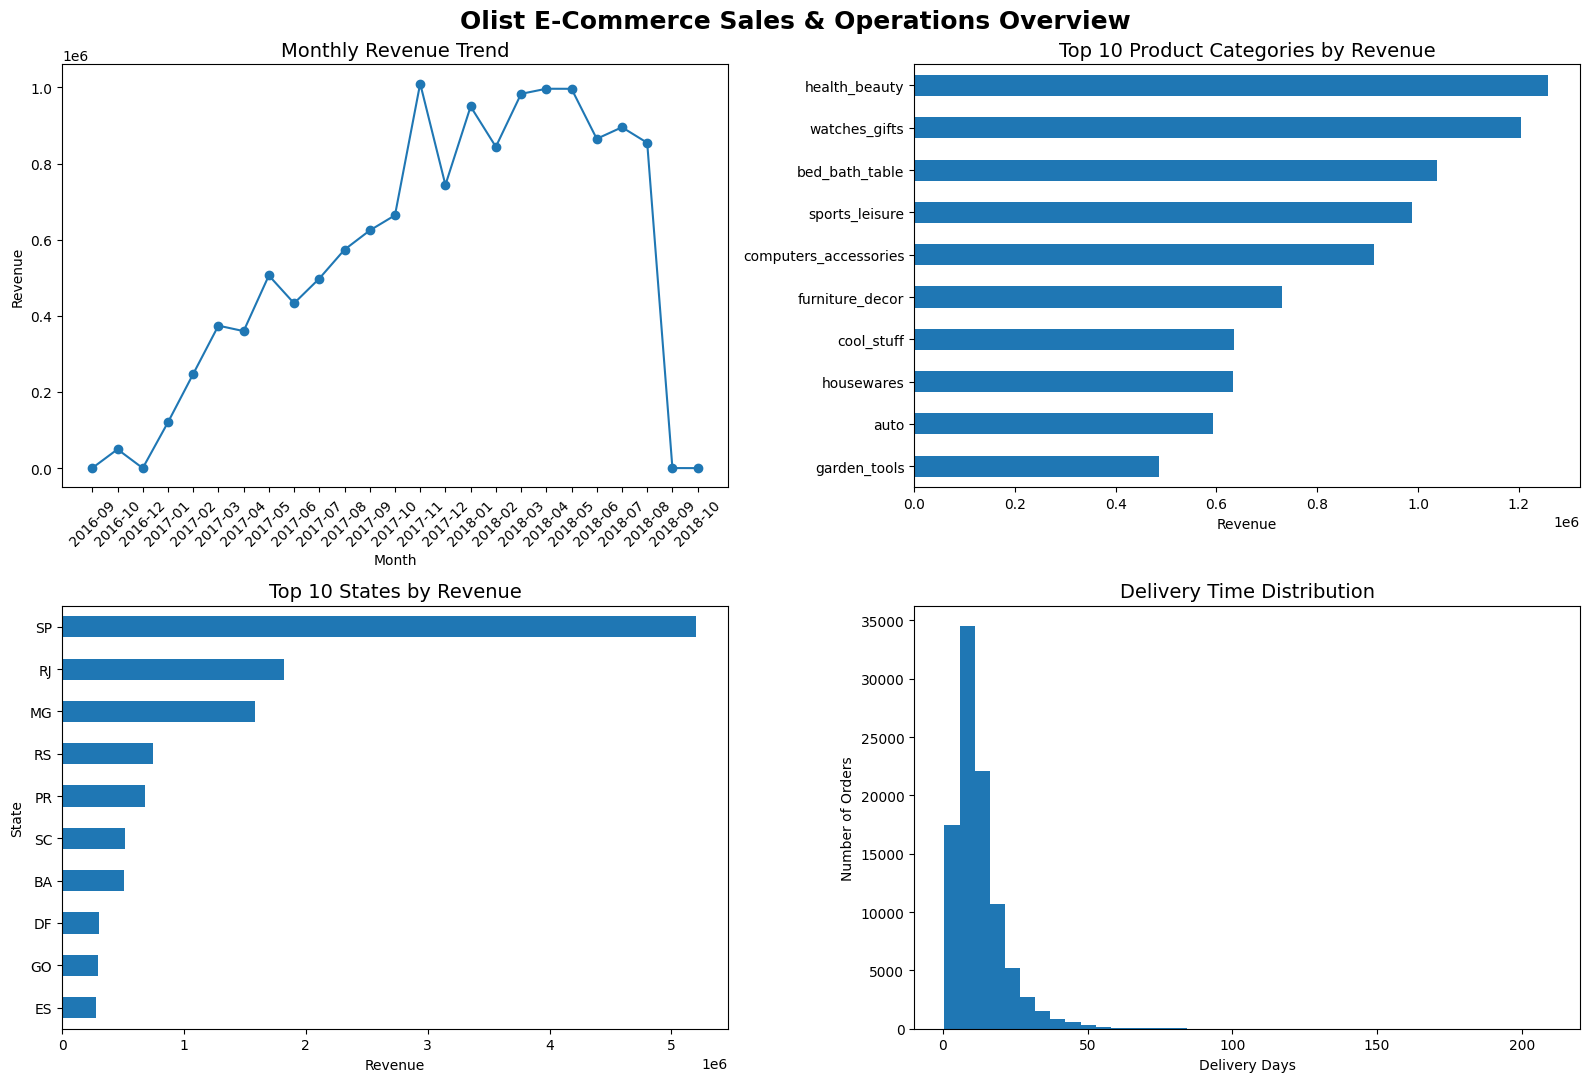

In [94]:
## Sales & Revenue Overview

# ==========================================
# SALES & REVENUE OVERVIEW
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Monthly sales
monthly_sales = (
    order_analysis
    .groupby("order_month")
    .agg(
        revenue=("product_revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

# Top categories
category_sales = (
    order_items_analysis
    .groupby("product_category")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

# Top 10 states
state_sales = (
    order_analysis
    .groupby("customer_state")
    .agg(
        revenue=("product_revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

# Delivery performance
delivery_data = order_analysis[
    order_analysis["delivery_days"].notna()
].copy()

# ==========================================
# 2 x 2 CHART FRAME
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Monthly Revenue
axes[0, 0].plot(
    monthly_sales["order_month"],
    monthly_sales["revenue"],
    marker="o"
)
axes[0, 0].set_title("Monthly Revenue Trend", fontsize=14)
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Top 10 Categories
category_sales.head(10)["revenue"].sort_values().plot(
    kind="barh",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Top 10 Product Categories by Revenue", fontsize=14)
axes[0, 1].set_xlabel("Revenue")
axes[0, 1].set_ylabel("")

# 3. Top 10 States
state_sales["revenue"].sort_values().plot(
    kind="barh",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Top 10 States by Revenue", fontsize=14)
axes[1, 0].set_xlabel("Revenue")
axes[1, 0].set_ylabel("State")

# 4. Delivery Distribution
axes[1, 1].hist(
    delivery_data["delivery_days"],
    bins=40
)
axes[1, 1].set_title("Delivery Time Distribution", fontsize=14)
axes[1, 1].set_xlabel("Delivery Days")
axes[1, 1].set_ylabel("Number of Orders")

plt.suptitle(
    "Olist E-Commerce Sales & Operations Overview",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Operations & Customer Experience Dashboard

This frame focuses on the two things that matter beyond sales:

<!-- Delivery performance
Customer experience
Freight burden
Category-level operational efficiency -->

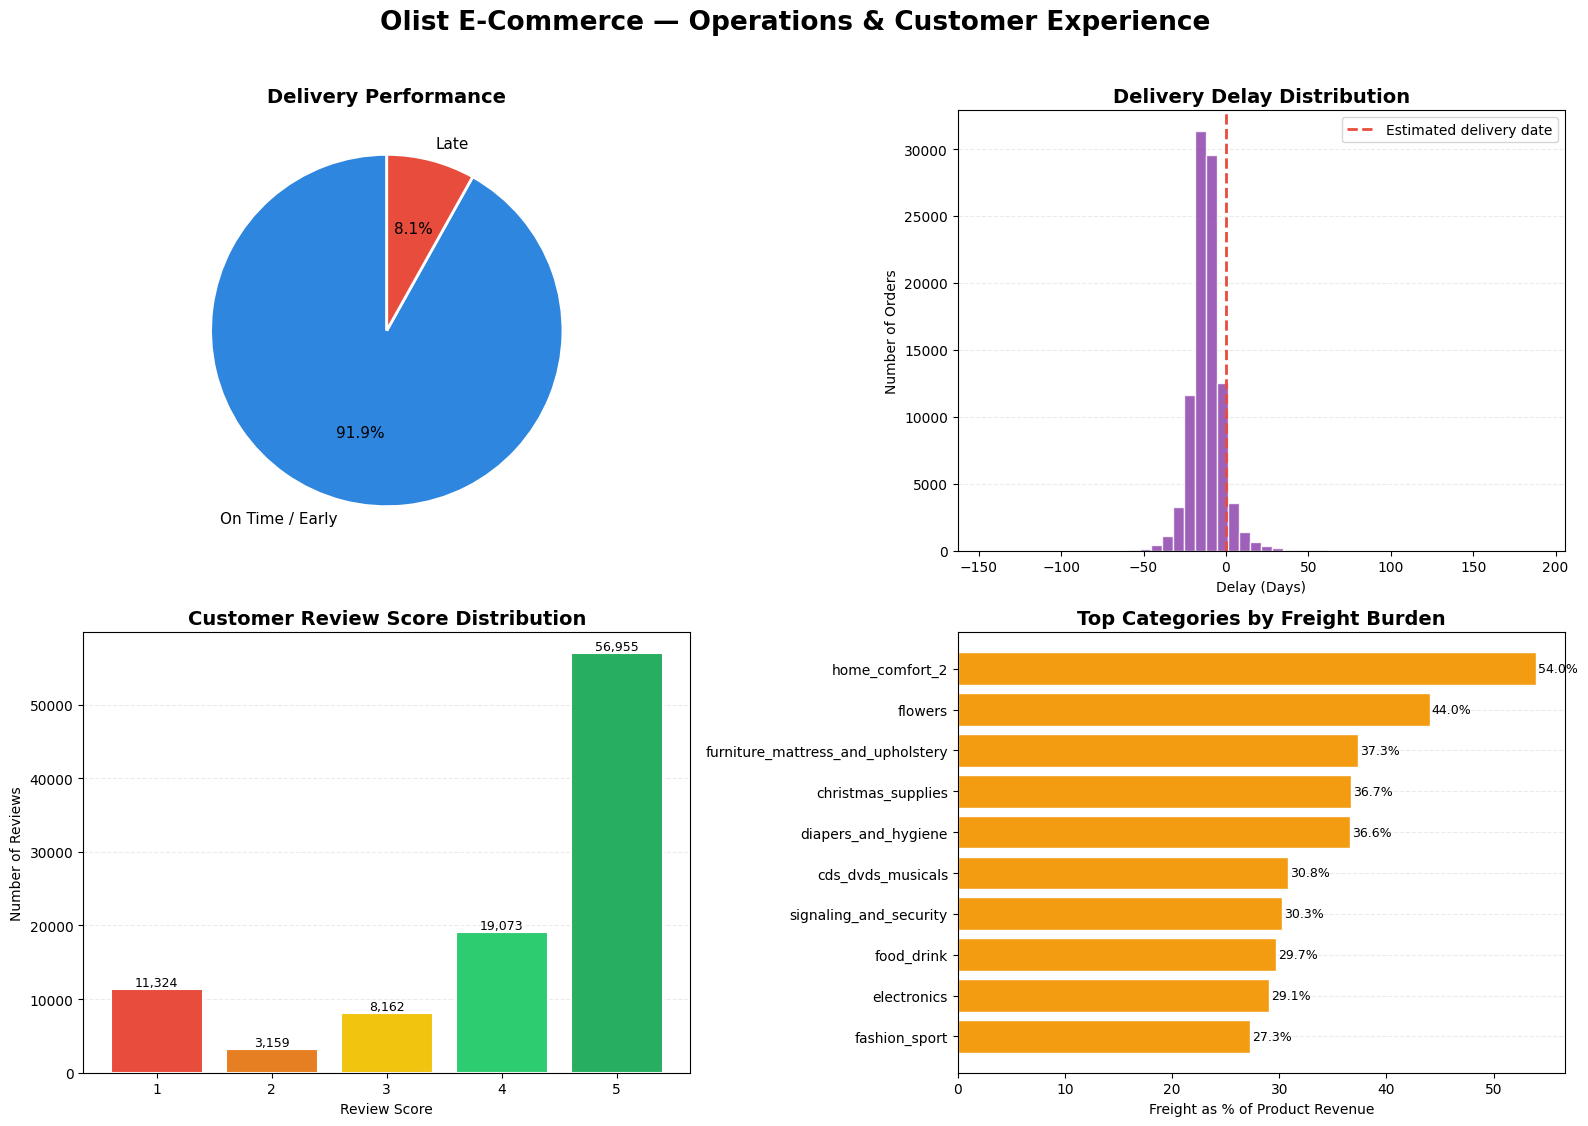

In [96]:
# ==========================================
# OPERATIONS & CUSTOMER EXPERIENCE DASHBOARD
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Prepare data ----------

# 1. On-time vs late delivery
delivery_status = (
    order_analysis[order_analysis["is_late"].notna()]
    .copy()
)

delivery_status["delivery_performance"] = np.where(
    delivery_status["is_late"],
    "Late",
    "On Time / Early"
)

delivery_counts = (
    delivery_status["delivery_performance"]
    .value_counts()
)

# 2. Delay distribution
delay_data = delivery_status["delivery_delay_days"].dropna()

# 3. Review score distribution
review_counts = (
    order_analysis["review_score"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

# 4. Freight ratio by category
category_freight = (
    order_items_analysis
    .groupby("product_category")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
)

category_freight["freight_ratio"] = (
    category_freight["freight"]
    / category_freight["revenue"]
)

category_freight = (
    category_freight
    .sort_values("freight_ratio", ascending=False)
    .head(10)
)

# ---------- Create dashboard ----------

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ==========================================
# 1. ON-TIME VS LATE
# ==========================================

colors_delivery = ["#2E86DE", "#E74C3C"]

wedges, texts, autotexts = axes[0, 0].pie(
    delivery_counts.values,
    labels=delivery_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_delivery,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)

axes[0, 0].set_title(
    "Delivery Performance",
    fontsize=14,
    fontweight="bold"
)

# ==========================================
# 2. DELIVERY DELAY DISTRIBUTION
# ==========================================

axes[0, 1].hist(
    delay_data,
    bins=50,
    color="#8E44AD",
    edgecolor="white",
    alpha=0.85
)

axes[0, 1].axvline(
    0,
    color="#E74C3C",
    linestyle="--",
    linewidth=2,
    label="Estimated delivery date"
)

axes[0, 1].set_title(
    "Delivery Delay Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Delay (Days)")
axes[0, 1].set_ylabel("Number of Orders")
axes[0, 1].legend()

# ==========================================
# 3. CUSTOMER REVIEW SCORE
# ==========================================

review_colors = [
    "#E74C3C",
    "#E67E22",
    "#F1C40F",
    "#2ECC71",
    "#27AE60"
]

bars = axes[1, 0].bar(
    review_counts.index.astype(str),
    review_counts.values,
    color=review_colors,
    edgecolor="white",
    linewidth=1.5
)

axes[1, 0].set_title(
    "Customer Review Score Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Review Score")
axes[1, 0].set_ylabel("Number of Reviews")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ==========================================
# 4. FREIGHT RATIO BY CATEGORY
# ==========================================

bars = axes[1, 1].barh(
    category_freight.index[::-1],
    category_freight["freight_ratio"][::-1] * 100,
    color="#F39C12",
    edgecolor="white"
)

axes[1, 1].set_title(
    "Top Categories by Freight Burden",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Freight as % of Product Revenue")
axes[1, 1].set_ylabel("")

# Add percentages
for bar in bars:
    width = bar.get_width()
    axes[1, 1].text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

# ==========================================
# FINAL FORMATTING
# ==========================================

for ax in axes.flat:
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )
    ax.set_axisbelow(True)

plt.suptitle(
    "Olist E-Commerce — Operations & Customer Experience",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

┌─────────────────────────────┬─────────────────────────────┐
│ 🟦 Delivery Performance    │ 🟪 Delivery Delay           │
│     On-time vs Late         │     Distribution            │
├─────────────────────────────┼─────────────────────────────┤
│ ⭐ Review Score             │ 🟧 Freight Burden           │
│     Distribution            │     by Category             │
└─────────────────────────────┴─────────────────────────────┘

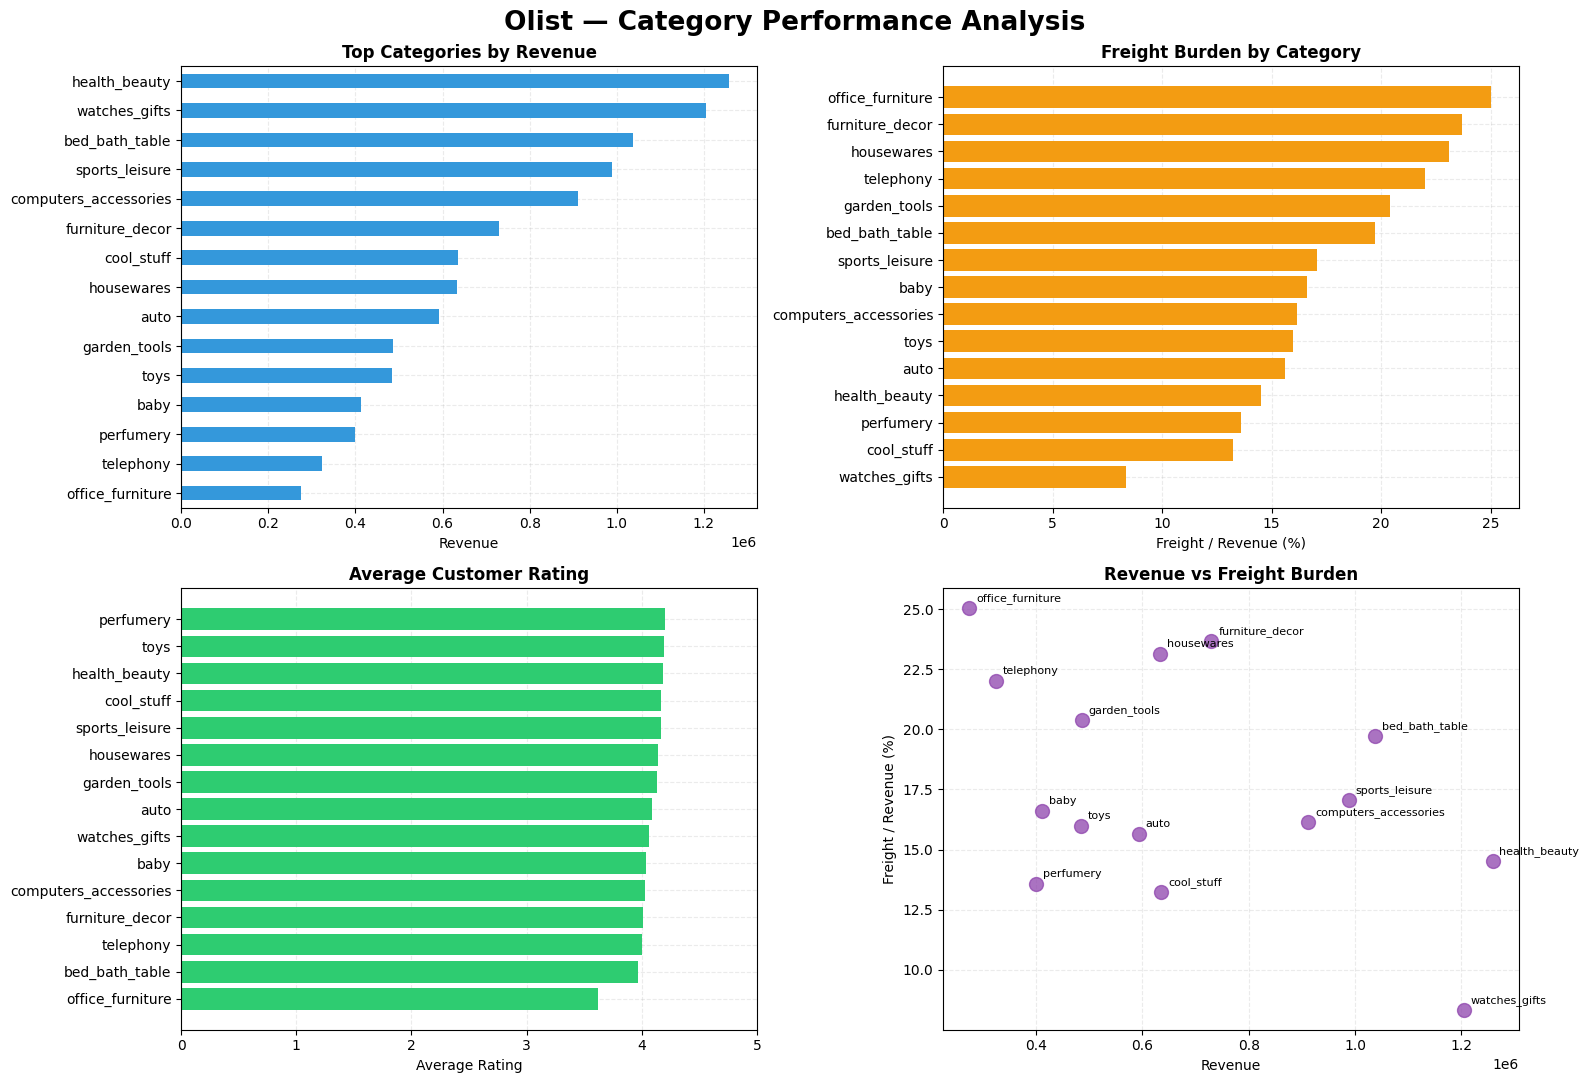

In [97]:
# Category Performance Matrix

# This is our final major EDA analysis 

# Why?

# We want to identify categories where sales, logistics, delivery, and customer experience interact.



# ==========================================
# CATEGORY PERFORMANCE ANALYSIS
# ==========================================

category_performance = (
    order_items_analysis
    .groupby("product_category")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        freight=("freight_value", "sum"),
        avg_rating=("order_id", lambda x:
                    order_analysis.loc[
                        order_analysis["order_id"].isin(x),
                        "review_score"
                    ].mean())
    )
    .reset_index()
)

# Freight burden
category_performance["freight_ratio"] = (
    category_performance["freight"]
    / category_performance["revenue"]
) * 100

# Keep meaningful categories
category_performance = category_performance[
    category_performance["orders"] >= 100
].copy()

# Top 15 by revenue
top_categories = (
    category_performance
    .sort_values("revenue", ascending=False)
    .head(15)
)

# ==========================================
# VISUALIZATION
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Revenue
top_categories.sort_values("revenue").plot(
    x="product_category",
    y="revenue",
    kind="barh",
    ax=axes[0, 0],
    legend=False,
    color="#3498DB"
)

axes[0, 0].set_title("Top Categories by Revenue", fontweight="bold")
axes[0, 0].set_xlabel("Revenue")
axes[0, 0].set_ylabel("")

# Freight ratio
freight_top = top_categories.sort_values("freight_ratio")

axes[0, 1].barh(
    freight_top["product_category"],
    freight_top["freight_ratio"],
    color="#F39C12"
)

axes[0, 1].set_title("Freight Burden by Category", fontweight="bold")
axes[0, 1].set_xlabel("Freight / Revenue (%)")
axes[0, 1].set_ylabel("")

# Average rating
rating_top = top_categories.sort_values("avg_rating")

axes[1, 0].barh(
    rating_top["product_category"],
    rating_top["avg_rating"],
    color="#2ECC71"
)

axes[1, 0].set_title("Average Customer Rating", fontweight="bold")
axes[1, 0].set_xlabel("Average Rating")
axes[1, 0].set_xlim(0, 5)

# Revenue vs freight
axes[1, 1].scatter(
    top_categories["revenue"],
    top_categories["freight_ratio"],
    s=100,
    color="#8E44AD",
    alpha=0.75
)

for _, row in top_categories.iterrows():
    axes[1, 1].annotate(
        row["product_category"],
        (row["revenue"], row["freight_ratio"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

axes[1, 1].set_title(
    "Revenue vs Freight Burden",
    fontweight="bold"
)
axes[1, 1].set_xlabel("Revenue")
axes[1, 1].set_ylabel("Freight / Revenue (%)")

for ax in axes.flat:
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

plt.suptitle(
    "Olist — Category Performance Analysis",
    fontsize=19,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

📊 Dashboard Analysis — Key Business Insights

Your dashboards are looking good. They already tell a strong sales + operations + customer experience story.

1. 📈 Revenue Trend — Strong growth, but dataset-end effects
Revenue generally increases strongly from late 2016 through 2017 and into 2018.
Several months in 2018 are around 0.9–1.0M revenue, showing the business reached a much higher sales level than in 2016.
There are sharp fluctuations between some months.
The drop to almost zero in Sep–Oct 2018 should NOT be interpreted as a business collapse. It is very likely related to the dataset's observation period ending around that time.
Business insight: The platform shows substantial growth over the observed period, but the final incomplete months should be excluded from growth-rate conclusions.
2. 🛍️ Product Categories — Revenue is concentrated

Top categories by revenue include:

Health & Beauty
Watches & Gifts
Bed/Bath/Table
Sports & Leisure
Computers & Accessories
Health & Beauty is clearly the largest revenue contributor among the displayed categories.
The top categories contribute substantially more revenue than the lower-ranked categories.
Business insight: Category-level revenue is concentrated, so category management and inventory/logistics decisions should pay particular attention to these major contributors.
3. 🌎 State Performance — São Paulo dominates
SP (São Paulo) is far ahead of every other state in revenue.
RJ and MG follow, but with a large gap from SP.
The remaining states contribute progressively smaller amounts.

Business insight: Revenue is geographically concentrated, with São Paulo being the dominant market in this dataset.

This makes state-level logistics planning particularly important.

4. 🚚 Delivery Performance — 91.9% on-time/early

Your strongest operational KPI is:

91.9% → On Time / Early
8.1% → Late

That's a useful headline KPI for the dashboard.

However, the delay distribution gives more detail:

Most deliveries are before the estimated date, hence the negative values.
The largest concentration appears roughly around −20 to 0 days.
There is a smaller positive tail representing late deliveries.
A few extreme delivery delays extend far beyond the normal range.

Business insight: Overall delivery performance is mostly positive, but the minority of late deliveries can still be investigated because extreme delays may disproportionately affect customer experience.

5. ⭐ Customer Reviews — Strongly positive, but polarized

The review distribution shows:

5-star: 56,955
4-star: 19,073
3-star: 8,162
2-star: 3,159
1-star: 11,324

The most important observation is the very large 5-star group.

Approximately 77% of recorded reviews are 4 or 5 stars, while roughly 15% are 1 or 2 stars.

This matches your overall:

Average rating = 4.09 / 5

Business insight: Customer sentiment is generally positive, but the sizeable 1-star segment deserves investigation, particularly against delivery delays and freight burden.

6. 💰 Freight Burden — Important category-level risk

This chart is particularly useful because it shows freight as a percentage of product revenue, not simply freight amount.

The highest ratios are:

Category	Freight / Revenue
Home Comfort 2	54.0%
Flowers	44.0%
Furniture Mattress & Upholstery	37.3%
Christmas Supplies	36.7%
Diapers & Hygiene	36.6%

This means, for example, that for Home Comfort 2, freight is about 54% of product revenue in this dataset.

Important: This does not mean freight itself is 54% of the selling price for every individual order. It is an aggregated category-level ratio.

Business insight

Some categories have a potentially significant logistics-cost burden relative to their sales value. These categories should be examined for:

product size/weight,
shipping distance,
seller location,
delivery network,
pricing/freight strategy.

🔥 Most Important Combined Insight

The real value of your project comes from connecting these charts, rather than looking at them independently:

Sales are concentrated in certain categories and geographies, while a smaller set of categories has disproportionately high freight burden. Overall delivery performance is strong at 91.9% on-time/early, but late deliveries and low ratings represent areas for operational investigation.

This gives us a much stronger portfolio story than simply saying "revenue increased."

In [100]:
'''Connect Jupyter to SQL Server
Why?

This creates the connection we'll use to send our cleaned Python data into SQL Server.'''

"Connect Jupyter to SQL Server\nWhy?\n\nThis creates the connection we'll use to send our cleaned Python data into SQL Server."

In [101]:
!pip install sqlalchemy pyodbc

[notice] A new release of pip is available: 25.1.1 -> 26.2.1


[notice] To update, run: python.exe -m pip install --upgrade pip

In [102]:
import sqlalchemy
import pyodbc

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'CAMWorks SQLite3 ODBC Driver', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [103]:
import pyodbc
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = r"DESKTOP-643PI6N\SQLEXPRESS"
database = "Olist_Analytics"
driver = "ODBC Driver 17 for SQL Server"

connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

connection_url = "mssql+pyodbc:///?odbc_connect=" + quote_plus(
    connection_string
)

engine = create_engine(connection_url)

In [104]:
from sqlalchemy import text

with engine.connect() as connection:
    result = connection.execute(
        text("SELECT DB_NAME() AS CurrentDatabase")
    )
    print(result.fetchone())

('Olist_Analytics',)


In [105]:
# Load order_analysis


order_analysis.to_sql(
    "order_analysis",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("order_analysis loaded successfully")

order_analysis loaded successfully


In [106]:
# Load order_items_analysis
order_items_analysis.to_sql(
    "order_items_analysis",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=5000
)

print("order_items_analysis loaded successfully")

order_items_analysis loaded successfully
